# Climate Change Trend Analysis and Forecasting

# Week 1 – Data Collection and Exploratory Data Analysis (EDA)

## 1.1 Objectives

## 1.2 Import Libraries

## 1.3 Dataset Download

## 1.4 Data Inspection

## 1.5 Missing Value Analysis

## 1.6 Exploratory Data Analysis

## 1.7 Week 1 Summary

- China
- United States
- India
- Russia
- Japan
- Germany
- Brazil
- United Kingdom
- South Africa
- Australia

Objectives:

1. Analyze historical emissions trends
2. Create time-series features
3. Train forecasting models
4. Predict future emissions
5. Compare forecasting approaches

In [1]:
import os

import urllib.request

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import matplotlib.ticker as mticker

Checking whether dataset exists locally.
If not available, download from OWID GitHub.

### Downloading the Dataset

The following code checks whether the OWID dataset already exists locally. If it is not available, it is downloaded from the official GitHub repository.

In [2]:
url = "https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv"

local_path = "data/owid-co2-data.csv"

if not os.path.exists(local_path):
    
    urllib.request.urlretrieve(url, local_path)

    print("Downloaded")

else:
    
    print("Already Exists")

Already Exists


### Loading the Dataset

The downloaded dataset is loaded into a pandas DataFrame. The dataset dimensions, column names, and sample records are displayed to understand its structure.

In [3]:
df = pd.read_csv(local_path)

print(df.shape)

print(df.columns.tolist())

(50411, 79)
['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_capita', 'methane', 'methane_per_capita', 'nitrous_oxide', 'nitrous_oxide_p

In [4]:
print(df.head(10))

df.tail(5)

       country  year iso_code  population  gdp  cement_co2  \
0  Afghanistan  1750      AFG   2802560.0  NaN         0.0   
1  Afghanistan  1751      AFG         NaN  NaN         0.0   
2  Afghanistan  1752      AFG         NaN  NaN         0.0   
3  Afghanistan  1753      AFG         NaN  NaN         0.0   
4  Afghanistan  1754      AFG         NaN  NaN         0.0   
5  Afghanistan  1755      AFG         NaN  NaN         0.0   
6  Afghanistan  1756      AFG         NaN  NaN         0.0   
7  Afghanistan  1757      AFG         NaN  NaN         0.0   
8  Afghanistan  1758      AFG         NaN  NaN         0.0   
9  Afghanistan  1759      AFG         NaN  NaN         0.0   

   cement_co2_per_capita  co2  co2_growth_abs  co2_growth_prct  ...  \
0                    0.0  NaN             NaN              NaN  ...   
1                    NaN  NaN             NaN              NaN  ...   
2                    NaN  NaN             NaN              NaN  ...   
3                    NaN  NaN    

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
50406,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,0.496,0.032,8.491,-1.776,-17.298,...,NaN,0.106,0.001,0.001,0.002,0.0,24.146,14.463,1.991,23.450
50407,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,0.542,0.034,10.223,1.732,20.398,...,NaN,0.105,0.001,0.001,0.002,0.0,27.907,16.408,2.137,20.899
50408,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,0.387,0.024,12.232,2.009,19.653,...,NaN,0.104,0.001,0.001,0.002,0.0,29.917,18.830,1.380,11.283
50409,Zimbabwe,2023,ZWE,16340829.0,NaN,0.387,0.024,13.443,1.211,9.904,...,NaN,0.103,0.001,0.001,0.002,0.0,31.029,20.318,1.876,13.957
50410,Zimbabwe,2024,ZWE,16634366.0,NaN,0.387,0.023,13.701,0.258,1.918,...,NaN,0.102,0.001,0.001,0.002,0.0,31.066,20.773,NaN,NaN


### Checking Missing Values

This section calculates the percentage of missing values for every column to evaluate data completeness.

In [5]:
missing = (df.isnull().sum()/len(df))*100
missing.to_frame("NULL%")

,NULL%
country,0.000000
year,0.000000
iso_code,15.732677
population,18.337268
gdp,69.746682
...,...
temperature_change_from_n2o,24.064192
total_ghg,24.322073
total_ghg_excluding_lucf,24.990577
trade_co2,90.652834


### Key Variables

- **country** – Name of the country.
- **year** – Observation year.
- **co2** – Annual carbon dioxide emissions.
- **co2_per_capita** – Carbon dioxide emissions per person.
- **methane** – Methane emissions.
- **nitrous_oxide** – Nitrous oxide emissions.
- **total_ghg** – Total greenhouse gas emissions.

In [6]:
required_cols = [
    'co2',
    'co2_per_capita',
    'methane',
    'nitrous_oxide',
    'total_ghg',
]

### Data Coverage by Country

The completeness of the selected greenhouse gas variables is calculated for every country to identify which countries contain the most complete historical records.

In [7]:
country_coverage = (df.groupby("country")[required_cols].apply(lambda data:data.notna().mean().mean()*100).sort_values(ascending=False))
country_coverage.head(10)

country
Mexico         98.628571
Cuba           98.628571
Uruguay        98.628571
Brazil         98.628571
Colombia       98.628571
Argentina      98.628571
Peru           98.628571
Romania        98.171429
Switzerland    98.171429
Chile          98.011050
dtype: float64

### Data Coverage by Year

The completeness of greenhouse gas variables is also examined across years to identify periods with the highest data availability.

In [8]:
year_coverage = (
    df.groupby("year")[required_cols]
      .apply(lambda x: x.notna().mean().mean()*100)
      .sort_values(ascending=False)
)
year_coverage.head(10)

year
2024    89.291339
2009    89.291339
1994    89.291339
1995    89.291339
1996    89.291339
1997    89.291339
1998    89.291339
1999    89.291339
2000    89.291339
2001    89.291339
dtype: float64

### Filtering the Dataset

The dataset is filtered to include observations from 1990 onwards for the ten selected project countries. Aggregated regions such as World, Asia and Europe are excluded because the project focuses only on sovereign nations.

In [9]:
df[["country","iso_code"]].drop_duplicates()
filtered_dataset = (df.dropna(subset=["iso_code"]))
countries = [
    "China",
    "United States",
    "India",
    "Russia",
    "Japan",
    "Germany",
    "Brazil",
    "United Kingdom",
    "South Africa",
    "Australia"
]

filtered_dataset = df[(df["year"] >= 1990) & (df["country"].isin(countries))].copy() 
filtered_dataset

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
3644,Australia,1990,AUS,17126304.0,4.641366e+11,3.463,0.202,278.061,21.223,8.263,...,0.666,1.693,0.007,0.008,0.017,0.002,538.479,336.927,-33.380,-12.005
3645,Australia,1991,AUS,17353191.0,4.613021e+11,3.183,0.183,279.437,1.376,0.495,...,0.643,1.687,0.007,0.008,0.017,0.002,522.525,339.829,-34.011,-12.171
3646,Australia,1992,AUS,17549286.0,4.786337e+11,2.923,0.167,284.433,4.996,1.788,...,0.699,1.680,0.007,0.008,0.017,0.002,568.962,346.607,-36.367,-12.786
3647,Australia,1993,AUS,17722905.0,5.015248e+11,3.005,0.170,288.780,4.347,1.528,...,0.810,1.677,0.007,0.008,0.017,0.002,580.666,350.855,-40.004,-13.853
3648,Australia,1994,AUS,17897433.0,5.279932e+11,3.484,0.195,293.613,4.833,1.674,...,0.924,1.671,0.007,0.008,0.018,0.002,554.084,353.411,-35.667,-12.148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48003,United States,2020,USA,339436156.0,1.802736e+13,40.688,0.120,4689.954,-545.958,-10.427,...,30.237,18.090,0.037,0.238,0.286,0.011,5758.456,5309.856,413.131,8.809
48004,United States,2021,USA,340161438.0,1.909938e+13,41.312,0.121,5020.111,330.157,7.040,...,31.844,17.980,0.037,0.240,0.288,0.011,6131.129,5675.305,469.552,9.353
48005,United States,2022,USA,341534041.0,1.949317e+13,41.884,0.123,5055.403,35.292,0.703,...,30.882,17.870,0.038,0.242,0.291,0.011,6201.504,5728.265,510.586,10.100
48006,United States,2023,USA,343477330.0,NaN,40.636,0.118,4918.407,-136.996,-2.710,...,31.847,17.759,0.038,0.245,0.294,0.011,6078.455,5606.243,513.252,10.435


In [10]:
df = df.sort_values(
    ['country','year']
)

In [11]:
df['country'].value_counts()

country
Afghanistan                  275
Africa                       275
Andorra                      275
Antarctica                   275
Asia                         275
                            ... 
Saint Pierre and Miquelon    174
Sint Maarten (Dutch part)    174
Wallis and Futuna            174
Ryukyu Islands (GCP)          52
Kuwaiti Oil Fires (GCP)       32
Name: count, Length: 254, dtype: int64

Plotting total global CO₂ emissions trend.

### Global CO₂ Emissions Trend

This visualization shows the overall trend in global carbon dioxide emissions from 1990 onwards.

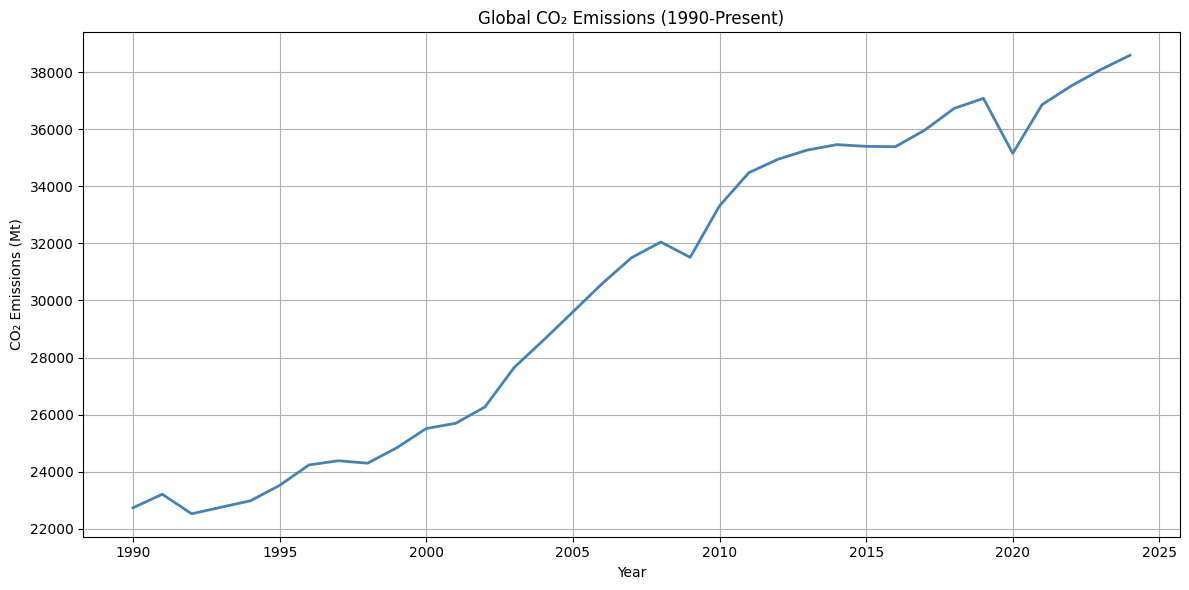

In [12]:
global_co2 = df[(df["country"]=="World")&(df["year"]>=1990)]
plt.figure(figsize=(12,6))

plt.plot(
    global_co2['year'],
    global_co2['co2'],
    color='steelblue',
    linewidth=2
)
plt.title("Global CO₂ Emissions (1990-Present)")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (Mt)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

Global CO₂ emissions increased steadily from 1990 onwards, with especially rapid growth during the 2000s. A temporary decline is visible around 2020 due to the COVID-19 pandemic before emissions recovered in later years.

### CO₂ Emission Trends of Major Emitters

The following chart compares historical CO₂ emissions for the five largest emitting countries included in this project.

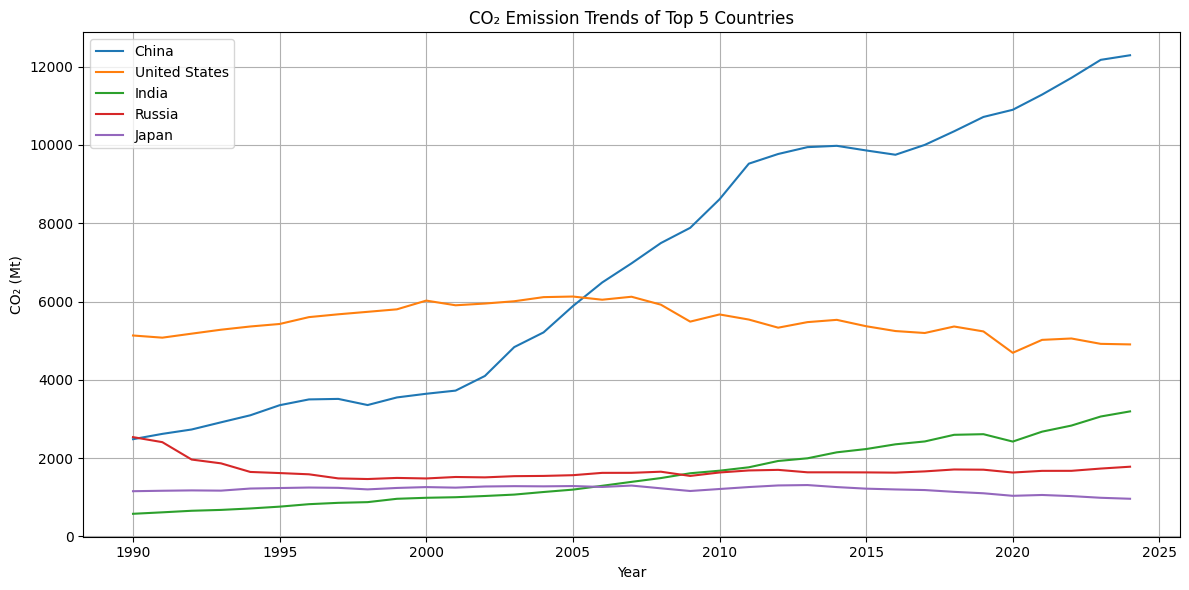

In [13]:
countries_emitters = [
'China',
'United States',
'India',
'Russia',
'Japan',
]
plt.figure(figsize=(12,6))
for country in countries_emitters:
    temp = filtered_dataset[filtered_dataset['country']==country]

    plt.plot(
        temp['year'],
        temp['co2'],
        label=country
    )

plt.title("CO₂ Emission Trends of Top 5 Countries")
plt.xlabel("Year")
plt.ylabel("CO₂ (Mt)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Observation

China shows the strongest increase in emissions after 2000. India also exhibits continuous growth, while the United States shows a gradual decline in recent years. Russia and Japan remain comparatively stable.

In [14]:
global_co2 = global_co2.copy()
global_co2['decade'] = (
    global_co2['year']//10
)*10

### Greenhouse Gas Composition by Decade

This chart compares the contribution of different greenhouse gases across decades.

In [15]:
gas = global_co2.groupby('decade')[
['co2','methane','nitrous_oxide']
].sum()

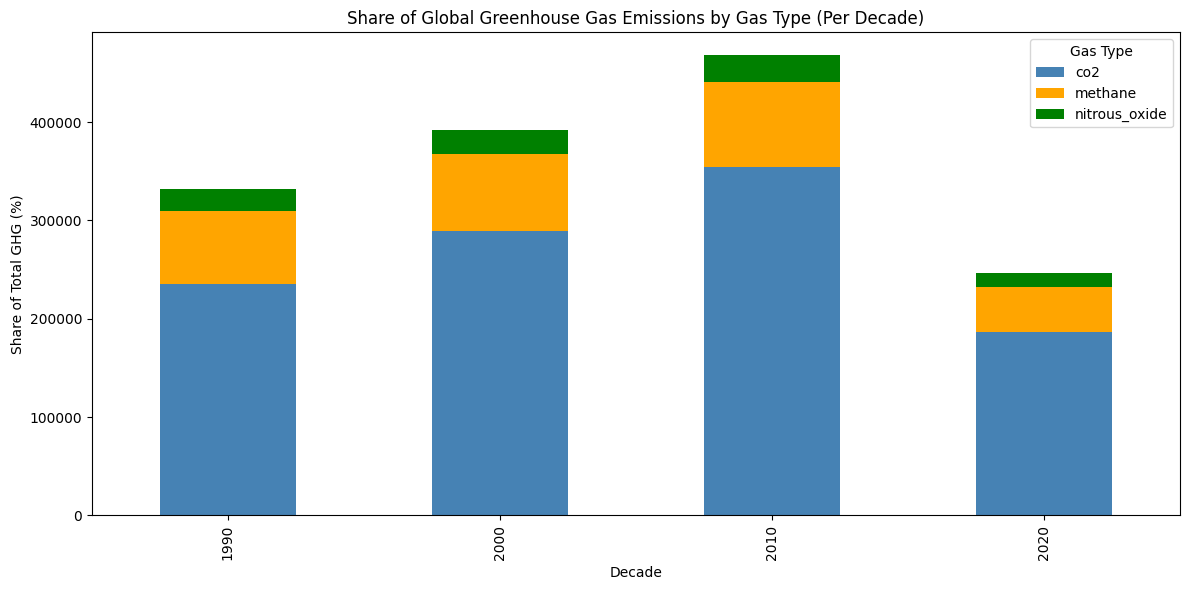

In [16]:
gas.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=['steelblue', 'orange', 'green']
)

plt.title("Share of Global Greenhouse Gas Emissions by Gas Type (Per Decade)")

plt.xlabel("Decade")

plt.ylabel("Share of Total GHG (%)")

plt.legend(title="Gas Type")

plt.tight_layout()

plt.show()

### Observation

Carbon dioxide contributes the largest share of greenhouse gas emissions across every decade. Methane represents the second largest contributor, while nitrous oxide remains comparatively smaller.

### Saving the Filtered Dataset

The cleaned dataset is saved for use in Week 2 feature engineering.

In [17]:
filtered_dataset.to_csv("data/filtered_dataset.csv",index=False)

## Week 1 Summary

In this notebook, the greenhouse gas emissions dataset was collected and explored. Missing values and data coverage were examined, and historical emission trends were visualized for the selected countries. The cleaned dataset will be used in the next stage for feature engineering.